# RQ3 Analysis (scalability of CRUD operations)

In [33]:
def shorten_x_axis_labels(ax):
    labels = [t.get_text() for t in ax.get_xticklabels()]

    new_labels = []
    for l in labels:
        try:
            val = float(l)

            if val >= 1_000_000:
                new_labels.append(f"{int(val/1_000_000)}M")
            elif val >= 1_000:
                new_labels.append(f"{int(val/1_000)}K")
            else:
                new_labels.append(str(int(val)))

        except:
            new_labels.append(l)

    ax.set_xticklabels(new_labels, rotation=0)

## Results

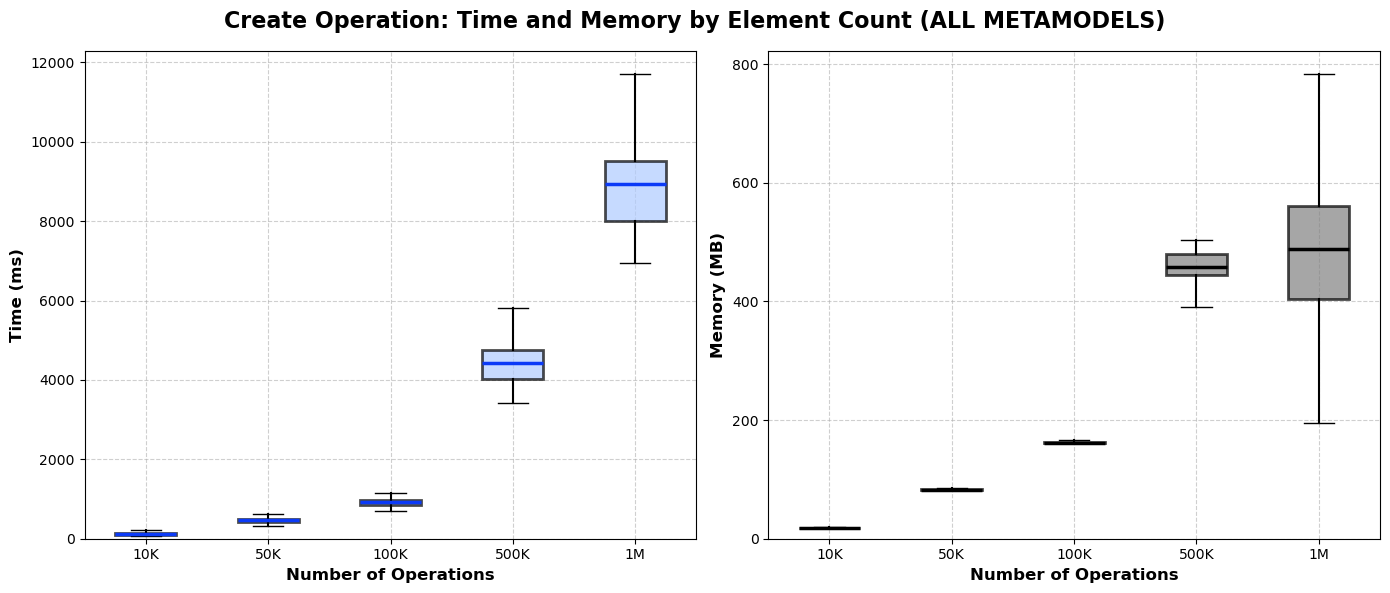

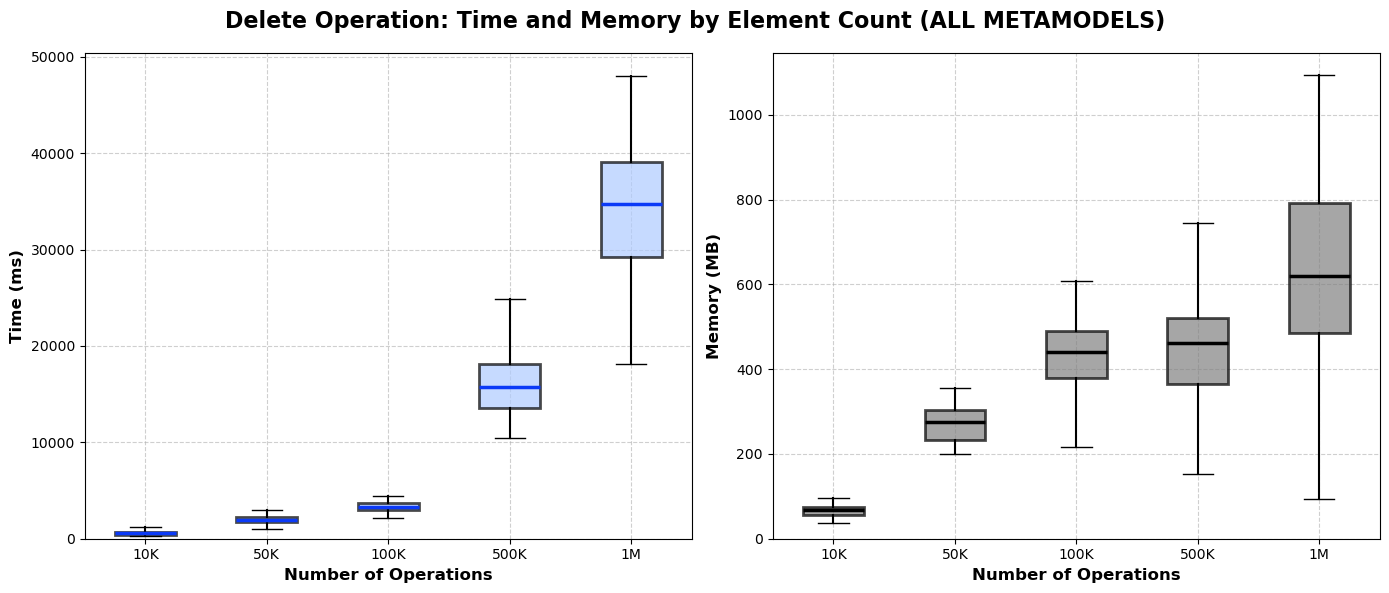

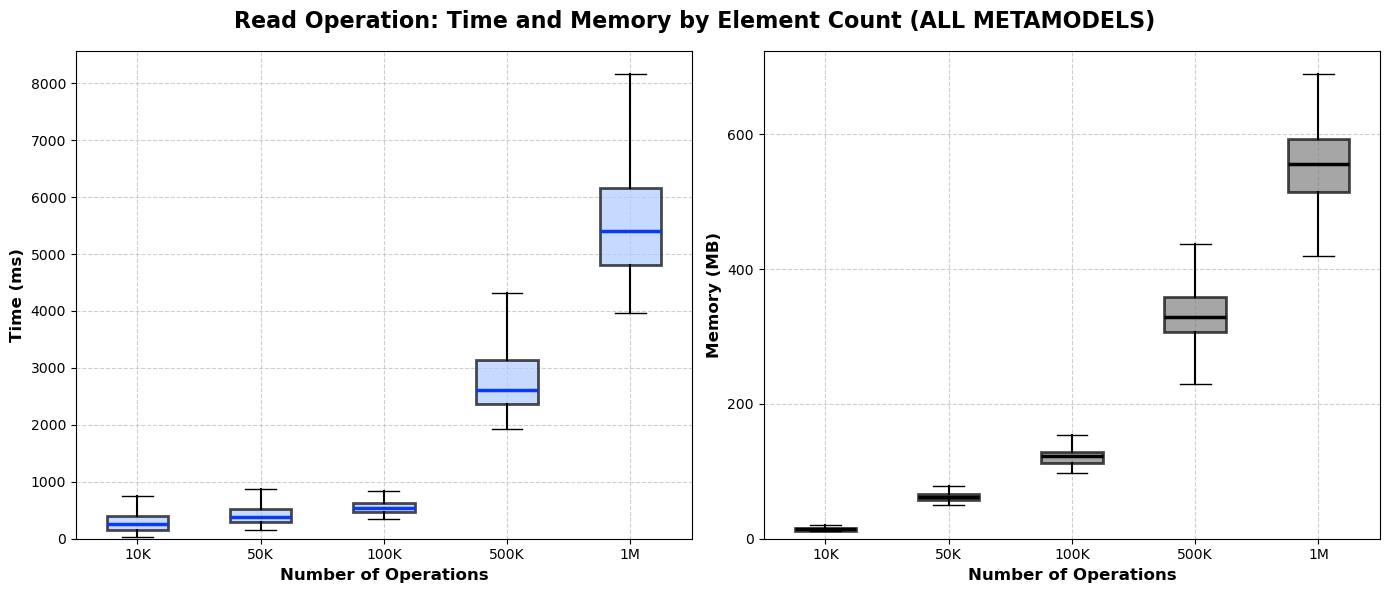

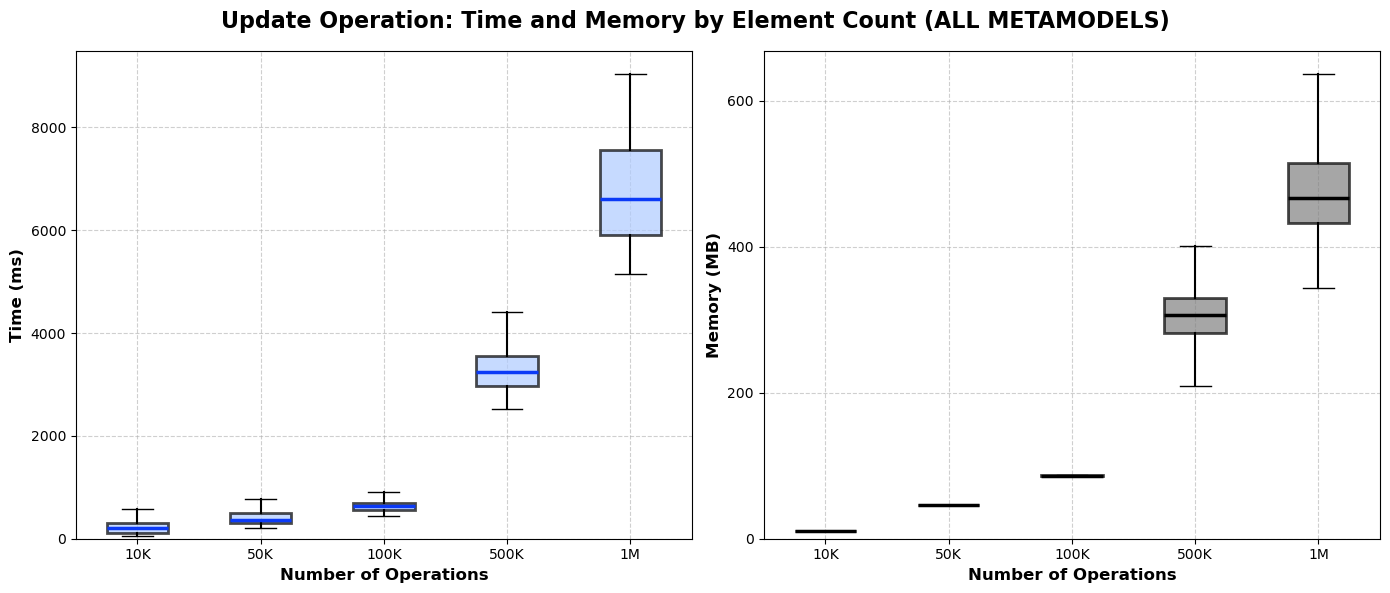

In [36]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE_FOLDER = "../results/RQ3GenModels"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


def plot_operation(df, op_name, metamodel_name):
    #df["time"] = df["time"] / 1000  
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # -------- TIME --------
    df.boxplot(
        column="time",
        by=group_col,
        ax=axes[0],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#AFCBFF", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="#0B3AF7", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[0].set_title("")
    axes[0].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Time (ms)", fontsize=12, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].set_ylim(bottom=0)

    # -------- MEM --------
    df.boxplot(
        column="mem",
        by=group_col,
        ax=axes[1],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="gray", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[1].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Memory (MB)", fontsize=12, fontweight="bold")

    axes[1].yaxis.set_major_locator(mticker.MultipleLocator(200 * 1024))
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x / 1024)}")
    )

    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].set_ylim(bottom=0)
    axes[1].set_title("")

    shorten_x_axis_labels(axes[0])
    shorten_x_axis_labels(axes[1])
    axes[0].set_ylim(bottom=0)
    axes[1].set_ylim(bottom=0)

    plt.suptitle(
        f"{op_name} Operation: Time and Memory by Element Count ({metamodel_name})",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    plt.show()


# ---------------- main loop -

operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue
 

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel  # kept for traceability (not used in plot)

        operations.setdefault(op, []).append(df)


for op, dfs in operations.items():
    full_df = pd.concat(dfs, ignore_index=True)

    # all metamodels combined
    plot_operation(full_df, op, "ALL METAMODELS")

In [35]:
import os
import re
import pandas as pd

BASE_FOLDER = "../results/RQ3GenModels"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


# ---- Helper ----
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - 1.5 * iqr) & (series <= q3 + 1.5 * iqr)]


# ---- LOAD DATA ----
operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel

        operations.setdefault(op, []).append(df)


# ---- ANALYSIS ----
for op, dfs in operations.items():
    print("\n===================================================")
    print(f"OPERATION: {op}")
    print("===================================================\n")

    df = pd.concat(dfs, ignore_index=True)

    # ---- GLOBAL ----
    print("---- GLOBAL STATS ----")
    for metric in ["time", "mem"]:
        s = df[metric]
        print(f"{metric.upper()}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}, max={s.max():.4f}")
    print()
 

    # ---- PER ELEMENT COUNT ----
    print("---- PER ELEMENT COUNT ----")
    grouped = df.groupby(group_col)

    for val, group in grouped:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{group_col}={val}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}")
    print()
 
    # ---- PER METAMODEL ----
    print("---- PER METAMODEL ----")
    grouped_meta = df.groupby("metamodel")

    for name, group in grouped_meta:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{name}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}, samples={len(group)}")
    print()

    # ---- WORST CASES (PER OPERATION TYPE) ----
    print("---- TOP 5 WORST CASES PER OPERATION TYPE ----")

    metrics = ["time", "mem"]

    for op_type in operations.keys():  # Create / Delete / Update / Read
        print(f"\n================ OPERATION: {op_type} ================")

        df_op = pd.concat(operations[op_type], ignore_index=True)

        for metric in metrics:
            print(f"\nWorst 5 by {metric}:")

            # take more candidates to allow dedup across time/mem later if needed
            candidates = df_op.nlargest(15, metric)

            selected = []
            seen = set()

            for _, row in candidates.iterrows():
                key = (row["metamodel"], row[group_col], row["time"], row["mem"])

                if key in seen:
                    continue

                seen.add(key)
                selected.append(row)

                if len(selected) == 5:
                    break

            result_df = pd.DataFrame(selected)[
                ["metamodel", group_col, "time", "mem"]
            ]

            print(result_df.to_string(index=False))


OPERATION: Create

---- GLOBAL STATS ----
TIME: mean=2963.1911, median=914.0000, std=3344.8496, max=12044.0000
MEM: mean=246707.0049, median=165888.0000, std=205405.9683, max=968858.0000

---- PER ELEMENT COUNT ----
element_count=10000: time_mean=111.6501, mem_mean=18815.4071
element_count=50000: time_mean=461.6607, mem_mean=84495.9081
element_count=100000: time_mean=908.8815, mem_mean=166399.3463
element_count=500000: time_mean=4428.5564, mem_mean=472041.7203
element_count=1000000: time_mean=8827.4777, mem_mean=489443.1659

---- PER METAMODEL ----
ApplauseDsl: time_mean=3108.4933, mem_mean=262878.9133, samples=150
AthenaDSL: time_mean=2859.9400, mem_mean=241725.2067, samples=150
AtsDsl: time_mean=2704.7933, mem_mean=209857.2933, samples=150
CoreDsl: time_mean=2666.3467, mem_mean=228374.5467, samples=150
CssExtDsl: time_mean=2715.8067, mem_mean=245932.5733, samples=150
DialogScript: time_mean=3052.6600, mem_mean=230510.8200, samples=150
EventOrientedLanguage: time_mean=3181.0467, mem_

## Least square method test

In [39]:
import pandas as pd
import numpy as np
import glob
import os
import re
from collections import defaultdict, Counter

base_folder = "../results/RQ3GenModels"
files = glob.glob(os.path.join(base_folder, "**/*.csv"), recursive=True)

pattern = re.compile(r"(.+)_run_\d+\.csv")

# ----------------------------
# GROUP BY OPERATION + METAMODEL
# ----------------------------
grouped = defaultdict(lambda: defaultdict(list))

for f in files:
    filename = os.path.basename(f)
    match = pattern.match(filename)
    if not match:
        continue

    op = match.group(1)
    metamodel = os.path.basename(os.path.dirname(f))

    grouped[op][metamodel].append(f)

print("Files:", len(files))
print("Operations:", len(grouped))


# ----------------------------
# MODELS
# ----------------------------
def r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot


def fit_linear(x, y):
    A = np.vstack([x, np.ones(len(x))]).T
    coef, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coef, coef[0] * x + coef[1]


def fit_exponential(x, y):
    y_safe = np.where(y <= 0, 1e-9, y)
    logy = np.log(y_safe)
    A = np.vstack([x, np.ones(len(x))]).T
    coef, _, _, _ = np.linalg.lstsq(A, logy, rcond=None)
    b, loga = coef
    a = np.exp(loga)
    return (a, b), a * np.exp(b * x)


def fit_poly(x, y, degree):
    coef = np.polyfit(x, y, degree)
    return coef, np.polyval(coef, x)


def model_complexity(name):
    if name == "linear":
        return 1
    if name == "exponential":
        return 2
    if name.startswith("poly"):
        return int(name.replace("poly", ""))
    return 10


def format_poly(coefs):
    terms = []
    degree = len(coefs) - 1
    for i, c in enumerate(coefs):
        power = degree - i
        if power == 0:
            terms.append(f"{c:.6e}")
        elif power == 1:
            terms.append(f"{c:.6e} * x")
        else:
            terms.append(f"{c:.6e} * x^{power}")
    return " + ".join(terms)


# ----------------------------
# CONFIG
# ----------------------------
metrics = ["time", "mem"]
poly_degrees = [2, 3, 4, 5]

folder_summaries = []


# ----------------------------
# MAIN LOOP
# ----------------------------
for op, meta_map in grouped.items():
    for metamodel, flist in meta_map.items():

        for metric in metrics:

            run_results = []
            per_run_best = []
            per_run_scores = []
            file_scores = []

            coefs_linear = []
            coefs_exp = []
            coefs_poly = {d: [] for d in poly_degrees}

            for f in flist:
                df = pd.read_csv(f)

                x = df["element_count"].values
                y = df[metric].values

                scores = {}

                # ---- models ----
                _, y_lin = fit_linear(x, y)
                scores["linear"] = r2(y, y_lin)

                _, y_exp = fit_exponential(x, y)
                scores["exponential"] = r2(y, y_exp)

                for d in poly_degrees:
                    _, y_poly = fit_poly(x, y, d)
                    scores[f"poly{d}"] = r2(y, y_poly)

                run_results.append(scores)
                per_run_scores.append(scores)
                file_scores.append((f, scores))

                # best model per run
                rounded_scores = {k: round(v, 2) for k, v in scores.items()}
                max_score = max(rounded_scores.values())
                candidates = [k for k, v in rounded_scores.items() if v == max_score]
                best = min(candidates, key=model_complexity)
                per_run_best.append(best)

                # coefficients
                lin_coef, _ = fit_linear(x, y)
                exp_coef, _ = fit_exponential(x, y)

                coefs_linear.append(lin_coef)
                coefs_exp.append(exp_coef)

                for d in poly_degrees:
                    coef, _ = fit_poly(x, y, d)
                    coefs_poly[d].append(coef)

            # ----------------------------
            # AGGREGATION
            # ----------------------------
            df_runs = pd.DataFrame(run_results)
            mean_scores = df_runs.mean()

            mean_lin = np.mean(coefs_linear, axis=0)
            mean_exp = np.mean(coefs_exp, axis=0)
            mean_poly = {d: np.mean(coefs_poly[d], axis=0) for d in poly_degrees}

            counts = Counter(per_run_best)
            best_model = counts.most_common(1)[0][0]
            consistency = counts[best_model] / len(per_run_best)

            eq_linear = f"y = {mean_lin[0]:.6e} * x + {mean_lin[1]:.6e}"
            eq_exp = f"y = {mean_exp[0]:.6e} * exp({mean_exp[1]:.6e} * x)"
            eq_polys = {f"poly{d}": f"y = {format_poly(mean_poly[d])}" for d in poly_degrees}

            equation = {
                "linear": eq_linear,
                "exponential": eq_exp,
                **eq_polys
            }

            # ----------------------------
            # WORST CASE (FIXED)
            # ----------------------------
            worst_file, worst_scores = min(
                file_scores,
                key=lambda x: x[1][best_model]
            )

            worst_model = min(worst_scores, key=worst_scores.get)

            # ----------------------------
            # OUTPUT
            # ----------------------------
            print("\n==============================")
            print("Operation:", op)
            print("Metamodel:", metamodel)
            print("Metric:", metric.upper())

            print("Best model (majority vote):", best_model)
            print("Consistency:", consistency)

            print("\nEquations:")
            for k, v in equation.items():
                print(f"  {k}: {v}")

            print("\nMean R²:")
            print(mean_scores)

            if consistency < 1.0:
                print("\n⚠️ Inconsistent runs")
                print("Per-run best:", per_run_best)
                print("Worst file:", os.path.basename(worst_file))
                print("Worst model in worst file:", worst_model)
                print("Worst scores:", worst_scores)

            folder_summaries.append({
                "operation": op,
                "metamodel": metamodel,
                "metric": metric,
                "best_model": best_model,
                "consistency": consistency,
                "linear_r2": mean_scores["linear"],
                "exponential_r2": mean_scores["exponential"],
                **{f"poly{d}_r2": mean_scores[f"poly{d}"] for d in poly_degrees},
                "worst_file": os.path.basename(worst_file),
                "worst_model": worst_model
            })


# ----------------------------
# SAVE SUMMARY
# ----------------------------
summary_df = pd.DataFrame(folder_summaries)
summary_df.to_csv("RQ3_Gen_trend_analysis.csv", index=False)

print("\nSaved: RQ3_Gen_trend_analysis.csv")

Files: 3600
Operations: 4

Operation: Create
Metamodel: ApplauseDsl
Metric: TIME
Best model (majority vote): linear
Consistency: 0.9333333333333333

Equations:
  linear: y = 9.416875e-03 * x + -1.790909e+01
  exponential: y = 3.170840e+02 * exp(3.837918e-06 * x)
  poly2: y = 4.944350e-10 * x^2 + 8.925593e-03 * x + 2.034178e+01
  poly3: y = 1.005001e-15 * x^3 + -1.026211e-09 * x^2 + 9.463673e-03 * x + -6.587642e-01
  poly4: y = 2.596467e-20 * x^4 + -4.072096e-14 * x^3 + 1.616572e-08 * x^2 + 8.013074e-03 * x + 1.932648e+01
  poly5: y = 1.742370e-26 * x^5 + -2.958671e-21 * x^4 + -2.771417e-14 * x^3 + 1.460108e-08 * x^2 + 8.071008e-03 * x + 1.889089e+01

Mean R²:
linear         0.998468
exponential    0.454503
poly2          0.999852
poly3          0.999981
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'poly2', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear

C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly con


Operation: Create
Metamodel: AtsDsl
Metric: MEM
Best model (majority vote): poly3
Consistency: 0.8

Equations:
  linear: y = 3.706766e-01 * x + 8.679266e+04
  exponential: y = 6.162702e+04 * exp(2.250203e-06 * x)
  poly2: y = -7.005501e-07 * x^2 + 1.066759e+00 * x + 3.259614e+04
  poly3: y = 1.702335e-12 * x^3 + -3.276318e-06 * x^2 + 1.978194e+00 * x + -2.975931e+03
  poly4: y = 7.083984e-18 * x^4 + -9.681830e-12 * x^3 + 1.414187e-06 * x^2 + 1.582425e+00 * x + 2.476677e+03
  poly5: y = 4.439094e-24 * x^5 + -2.849119e-19 * x^4 + -6.368046e-12 * x^3 + 1.015556e-06 * x^2 + 1.597185e+00 * x + 2.365700e+03

Mean R²:
linear         0.752868
exponential    0.268925
poly2          0.980501
poly3          0.999770
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly2', 'poly3', 'poly3', 'poly2', 'poly2', 'poly3', 'poly3', 'poly3', 'poly3', 'pol

C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly con


Operation: Create
Metamodel: CssExtDsl
Metric: MEM
Best model (majority vote): poly2
Consistency: 1.0

Equations:
  linear: y = 4.772108e-01 * x + 8.749858e+04
  exponential: y = 6.180680e+04 * exp(2.527089e-06 * x)
  poly2: y = -8.725466e-07 * x^2 + 1.344193e+00 * x + 1.999594e+04
  poly3: y = 1.024011e-12 * x^3 + -2.421957e-06 * x^2 + 1.892452e+00 * x + -1.401852e+03
  poly4: y = 4.173899e-18 * x^4 + -5.683564e-12 * x^3 + 3.416987e-07 * x^2 + 1.659263e+00 * x + 1.810837e+03
  poly5: y = 2.600353e-24 * x^5 + -1.426868e-19 * x^4 + -3.742400e-12 * x^3 + 1.081870e-07 * x^2 + 1.667910e+00 * x + 1.745828e+03

Mean R²:
linear         0.834402
exponential    0.226494
poly2          0.996507
poly3          0.999955
poly4          1.000000
poly5          1.000000
dtype: float64

Operation: Create
Metamodel: DialogScript
Metric: TIME
Best model (majority vote): linear
Consistency: 1.0

Equations:
  linear: y = 8.909749e-03 * x + 9.462325e+01
  exponential: y = 4.539217e+02 * exp(3.363729e-06 *

...

C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly con


Operation: Update
Metamodel: StaticScript
Metric: TIME
Best model (majority vote): linear
Consistency: 0.9666666666666667

Equations:
  linear: y = 5.649465e-03 * x + 1.351977e+02
  exponential: y = 3.636141e+02 * exp(3.108964e-06 * x)
  poly2: y = 3.535894e-10 * x^2 + 5.298130e-03 * x + 1.625524e+02
  poly3: y = -1.593050e-15 * x^3 + 2.764001e-09 * x^2 + 4.445207e-03 * x + 1.958408e+02
  poly4: y = 1.205501e-21 * x^4 + -3.530325e-15 * x^3 + 3.562197e-09 * x^2 + 4.377857e-03 * x + 1.967687e+02
  poly5: y = 1.153201e-27 * x^5 + -7.088120e-22 * x^4 + -2.669460e-15 * x^3 + 3.458640e-09 * x^2 + 4.381692e-03 * x + 1.967399e+02

Mean R²:
linear         0.997994
exponential    0.727769
poly2          0.998951
poly3          0.999496
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'li

C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly con


Operation: Update
Metamodel: widget
Metric: TIME
Best model (majority vote): linear
Consistency: 0.8

Equations:
  linear: y = 6.773817e-03 * x + 4.057281e+01
  exponential: y = 2.782775e+02 * exp(3.621326e-06 * x)
  poly2: y = -6.699754e-10 * x^2 + 7.439520e-03 * x + -1.125836e+01
  poly3: y = -4.045124e-15 * x^3 + 5.450620e-09 * x^2 + 5.273748e-03 * x + 7.326876e+01
  poly4: y = 1.748422e-20 * x^4 + -3.214276e-14 * x^3 + 1.702741e-08 * x^2 + 4.296937e-03 * x + 8.672652e+01
  poly5: y = 1.269341e-26 * x^5 + -3.586848e-21 * x^4 + -2.266713e-14 * x^3 + 1.588754e-08 * x^2 + 4.339143e-03 * x + 8.640919e+01

Mean R²:
linear         0.997687
exponential    0.497180
poly2          0.999471
poly3          0.999972
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['linear', 'linear', 'linear', 'poly2', 'linear', 'linear', 'poly2', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'lin

C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_26556\2825885864.py:59: RankWarning: Polyfit may be poorly con

In [43]:
import pandas as pd

df = pd.read_csv("RQ3_Gen_trend_analysis.csv")

summary = df.groupby("best_model").agg(
    occurrences=("best_model", "count"),
    operations=("operation", lambda x: sorted(x.unique())),
    metamodels=("metamodel", lambda x: sorted(x.unique()))
).reset_index()

for _, row in summary.iterrows():
    ops = ", ".join(row["operations"])
    metas = ", ".join(row["metamodels"])

    print(f"\n{row['best_model']} was found {row['occurrences']} times")
    print(f"  Operations: {ops}")
    print(f"  Metamodels: {metas}")


linear was found 96 times
  Operations: Create, Delete, Read, Update
  Metamodels: ApplauseDsl, AthenaDSL, AtsDsl, CoreDsl, CssExtDsl, DialogScript, EventOrientedLanguage, FlatQVT, FractalItf, Glsl, Iptables, JavaVMTypes, LLVM_IR, MDD, NetModel, OseeDsl, RobotTask, SqliteModel, StaticScript, Transformation, business, environment, erlang, esb, hockeyleague, java5, modelica, reviews, timing-diagram, widget

poly2 was found 85 times
  Operations: Create, Delete, Read, Update
  Metamodels: ApplauseDsl, AthenaDSL, AtsDsl, CoreDsl, CssExtDsl, DialogScript, EventOrientedLanguage, FlatQVT, FractalItf, Glsl, Iptables, JavaVMTypes, LLVM_IR, MDD, NetModel, OseeDsl, RobotTask, SqliteModel, StaticScript, Transformation, business, environment, erlang, esb, hockeyleague, java5, modelica, reviews, timing-diagram, widget

poly3 was found 48 times
  Operations: Create, Delete, Read
  Metamodels: ApplauseDsl, AthenaDSL, AtsDsl, CssExtDsl, DialogScript, EventOrientedLanguage, FlatQVT, FractalItf, Glsl, I